# PDEBench-Lang: BART Baseline for PDE Classification

**Goal:** First-pass notebook baseline using T5-small with natural language dialect input.

**Target:** Single concatenated seq2seq output containing:
- Behavioral label (PDE family)
- Operators
- Reasoning chain

**Budget:** 3 epochs on full dataset

## Phase 1: Data/Task Setup

In [39]:
# Install required packages in the active kernel environment
import sys
!{sys.executable} -m pip install -q "transformers[torch]" "accelerate>=1.1.0" datasets evaluate rouge_score scikit-learn

In [40]:
import json
import os
import random
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    BartTokenizer,
    BartForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
import evaluate

# Set reproducible config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Configuration
CONFIG = {
    "model_name": "facebook/bart-base",
    "max_input_length": 128,
    "max_output_length": 256,
    "learning_rate": 3e-4,
    "batch_size": 16,
    "num_epochs": 3,
    "val_split": 0.1,
    "seed": SEED,
}
DIALECTS = ["natural", "latex", "prefix", "postfix"]
MODELS_DIR = "./models"
LOG_DIR = "./logs"
os.environ["TENSORBOARD_LOGGING_DIR"] = LOG_DIR
os.makedirs(LOG_DIR, exist_ok=True)

print(f"Configuration: {CONFIG}")
print(f"Dialects: {DIALECTS}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():  # Mac with Apple Silicon
    device = torch.device("mps")
else:
    device = torch.device("cpu")

use_cuda = device.type == "cuda"
if use_cuda:

    torch.backends.cudnn.benchmark = True

print(f"Using device: {device}")
print(f"CUDA acceleration enabled: {use_cuda}")

Configuration: {'model_name': 'facebook/bart-base', 'max_input_length': 128, 'max_output_length': 256, 'learning_rate': 0.0003, 'batch_size': 16, 'num_epochs': 3, 'val_split': 0.1, 'seed': 42}
Dialects: ['natural', 'latex', 'prefix', 'postfix']
Using device: mps
CUDA acceleration enabled: False


In [41]:
# Load dataset and validate schema
def load_dataset_jsonl(filepath):
    """Load dataset from JSONL file and validate required fields."""
    data = []
    required_fields = ["family", "dialects", "labels"]

    with open(filepath, "r") as f:
        for line_num, line in enumerate(f, 1):
            instance = json.loads(line.strip())

            # Validate schema
            for field in required_fields:
                if field not in instance:
                    raise ValueError(f"Line {line_num}: Missing required field '{field}'")

            # Validate nested fields
            for dialect in DIALECTS:
                if dialect not in instance["dialects"]:
                    raise ValueError(f"Line {line_num}: Missing 'dialects.{dialect}'")
            if "behavioral" not in instance["labels"]:
                raise ValueError(f"Line {line_num}: Missing 'labels.behavioral'")
            if "operators" not in instance["labels"]:
                raise ValueError(f"Line {line_num}: Missing 'labels.operators'")
            if "reasoning" not in instance["labels"]:
                raise ValueError(f"Line {line_num}: Missing 'labels.reasoning'")

            data.append(instance)

    return data

# Load the dataset
dataset_path = "varied_data_generation/dataset.jsonl"
raw_data = load_dataset_jsonl(dataset_path)

print(f"Loaded {len(raw_data)} instances")
print(f"\nSample instance:")
print(json.dumps(raw_data[0], indent=2))

Loaded 10000 instances

Sample instance:
{
  "family": "Advection",
  "coefficients": {
    "c": 1.23
  },
  "dialects": {
    "latex": "\\frac{\\partial}{\\partial t} u{\\left(t,x \\right)} + 1.23 \\frac{\\partial}{\\partial x} u{\\left(t,x \\right)} = 0",
    "prefix": "=(+(*(1.23000000000000, d(u(t, x), x)), d(u(t, x), t)), 0)",
    "postfix": "1.23000000000000 u(t, x) x d * u(t, x) t d + 0 =",
    "natural": "u propagates without diffusion: u_t plus 1.23 times u_x equals zero."
  },
  "labels": {
    "behavioral": "Advection",
    "operators": [
      "exp",
      "polynomial"
    ],
    "reasoning": "No second-order spatial derivative; only u_t and 1.23*u_x appear \u2014 this is advection, not diffusion, at speed 1.23."
  }
}


In [42]:
# Analyze family distribution
from collections import Counter

family_counts = Counter(instance["family"] for instance in raw_data)
print("PDE Family Distribution:")
print("-" * 30)
for family, count in sorted(family_counts.items()):
    print(f"{family}: {count} ({count/len(raw_data)*100:.1f}%)")

PDE Family Distribution:
------------------------------
Advection: 2000 (20.0%)
Burgers: 2000 (20.0%)
Heat: 2000 (20.0%)
Laplace: 2000 (20.0%)
Wave: 2000 (20.0%)


In [43]:
# Define input extractor for BART classification
def extract_text(instance, dialect="natural"):
    """Return a PDE description in the selected dialect."""
    return instance["dialects"][dialect]

# Extract the label (PDE family)
def extract_label(instance):
    """Return the PDE family label."""
    return instance["labels"]["behavioral"]

# Preview example
sample = raw_data[10]

print("Input samples by dialect:")
for dialect in DIALECTS:
    print(f"{dialect}: {extract_text(sample, dialect)}")

print("\nLabel:")
print(extract_label(sample))

Input samples by dialect:
natural: Wave propagation with speed 2.0: the second-order time change equals 2.0^2 times the second-order spatial change.
latex: \frac{\partial^{2}}{\partial t^{2}} u{\left(t,x \right)} = 4.0 \frac{\partial^{2}}{\partial x^{2}} u{\left(t,x \right)}
prefix: =(d(d(u(t, x), t), t), *(4.00000000000000, d(d(u(t, x), x), x)))
postfix: u(t, x) t d t d 4.00000000000000 u(t, x) x d x d * =

Label:
Wave


In [44]:
# Build label mappings
families = sorted(set(extract_label(d) for d in raw_data))

label2id = {f: i for i, f in enumerate(families)}
id2label = {i: f for f, i in label2id.items()}

print("Label mapping:")
print(label2id)

Label mapping:
{'Advection': 0, 'Burgers': 1, 'Heat': 2, 'Laplace': 3, 'Wave': 4}


## Phase 2: Training Pipeline

In [45]:
# Build stratified train/validation/test split by family
labels = [instance["family"] for instance in raw_data]

train_val, test_data = train_test_split(
    raw_data,
    test_size=0.1,
    stratify=labels,
    random_state=CONFIG["seed"]
)

train_data, val_data = train_test_split(
    train_val,
    test_size=CONFIG["val_split"] / (1.0 - CONFIG["val_split"]),
    stratify=[d["family"] for d in train_val],
    random_state=CONFIG["seed"],
)

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

# Verify balanced distribution
train_families = Counter(d["family"] for d in train_data)
val_families = Counter(d["family"] for d in val_data)
test_families = Counter(d["family"] for d in test_data)

print("\nTrain distribution:")
for family, count in sorted(train_families.items()):
    print(f"  {family}: {count}")

print("\nValidation distribution:")
for family, count in sorted(val_families.items()):
    print(f"  {family}: {count}")

print("\nTest distribution:")
for family, count in sorted(test_families.items()):
    print(f"  {family}: {count}")

Train size: 7999
Validation size: 1001
Test size: 1000

Train distribution:
  Advection: 1600
  Burgers: 1600
  Heat: 1600
  Laplace: 1599
  Wave: 1600

Validation distribution:
  Advection: 200
  Burgers: 200
  Heat: 200
  Laplace: 201
  Wave: 200

Test distribution:
  Advection: 200
  Burgers: 200
  Heat: 200
  Laplace: 200
  Wave: 200


In [46]:
# Initialize tokenizer and model
# Note: `facebook/bart-base` does not include a pretrained classification head,
# so the classification head weights are initialized randomly and must be trained.
tokenizer = BartTokenizer.from_pretrained(CONFIG["model_name"])
model = BartForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)
model.to(device)


print(f"Model loaded: {CONFIG['model_name']}")
print(f"Model parameters: {model.num_parameters():,}")

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: facebook/bart-base
Model parameters: 140,014,853


In [47]:
# Preprocess and tokenize for BART classification

def preprocess_data(data):
    """Convert raw data into text and label."""

    texts = [d["dialects"]["natural"] for d in data]
    labels = [label2id[d["labels"]["behavioral"]] for d in data]

    return {
        "text": texts,
        "label": labels
    }


def tokenize_function(examples):
    """Tokenize text inputs for BART."""

    tokenized = tokenizer(
        examples["text"],
        max_length=CONFIG["max_input_length"],
        truncation=True,
        padding="max_length"
    )

    tokenized["labels"] = examples["label"]

    return tokenized


# Create datasets
train_processed = preprocess_data(train_data)
val_processed = preprocess_data(val_data)

train_dataset = Dataset.from_dict(train_processed)
val_dataset = Dataset.from_dict(val_processed)


# Tokenize datasets
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "label"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "label"]
)


print(f"Train dataset: {len(train_tokenized)} examples")
print(f"Validation dataset: {len(val_tokenized)} examples")

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Train dataset: 7999 examples
Validation dataset: 1001 examples


In [48]:
# Check input truncation for BART classification
def check_truncation(data, max_input):
    """Check how many examples exceed the input token limit."""

    input_truncated = 0

    for instance in data:
        text = instance["dialects"]["natural"]

        tokens = tokenizer(
            text,
            return_length=True,
            padding=False,
            truncation=False,
        )["length"]

        if isinstance(tokens, list):
            tokens = tokens[0]

        if tokens > max_input:
            input_truncated += 1

    return input_truncated


input_trunc = check_truncation(
    raw_data,
    CONFIG["max_input_length"]
)

print(
    f"Input truncation: {input_trunc}/{len(raw_data)} "
    f"({input_trunc/len(raw_data)*100:.2f}%)"
)

Input truncation: 0/10000 (0.00%)


In [49]:
# Setup training arguments
training_args = TrainingArguments(
    output_dir="./bart_pde_results",
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    learning_rate=CONFIG["learning_rate"],
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    load_best_model_at_end=True,
    fp16=use_cuda,
)


# Data collator
# The Trainer will automatically place tensors on the selected device.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [50]:
# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
)

print("Trainer initialized successfully")

Trainer initialized successfully


In [51]:
# Train the model
print("Starting training...")
train_result = trainer.train()

print("\nTraining complete!")
print(f"Training loss: {train_result.training_loss:.4f}")

Starting training...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,0.091000,0.000058
2,0.014300,0.000031
3,0.000000,0.000022


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/configuration_utils.py:461: UserWarning: Some non-default generation parameters are set in the model config. These should go into either a) `model.generation_config` (as opposed to `model.config`); OR b) a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model).This warning will become an exception in the future.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/configuration_ut


Training complete!
Training loss: 0.0351


## Phase 3: Multitask BART Upgrade

This phase replaces the old family-only cross-dialect loop with the stronger multitask BART workflow.

What changes here:
- mixed-dialect training across natural, LaTeX, prefix, and postfix
- explicit dialect tags such as `[DIALECT_LATEX]`
- family classification plus operator prediction
- auxiliary structural targets: time order, spatial derivatives, nonlinearity, and spatial variable count
- optional held-out evaluation on every `varied_data_generation/held_out*.jsonl` file

For unseen held-out families like Beam, KleinGordon, and ReactionDiffusion, family accuracy is reported as unavailable while operator/structure metrics and the top predicted seen family are still shown.


### How To Read The Metrics

`family_accuracy`
- This is standard multiclass accuracy for the family head.
- For each example, the model predicts exactly one seen PDE family such as `Heat`, `Wave`, or `Burgers`.
- The score is `correct family predictions / total labeled examples`.
- Interpretation: this tells us whether the model can name the correct PDE family, but it does **not** by itself prove structural understanding.
- For held-out datasets with unseen labels like `Beam`, `KleinGordon`, or `ReactionDiffusion`, this is shown as `n/a` because those labels were never in the training family vocabulary.

`operator_micro_f1`
- This is a **multi-label** metric over the operator set, not a single-label accuracy.
- Every operator decision for every example is treated as a binary prediction, then all true positives, false positives, and false negatives are aggregated before computing F1.
- Interpretation: this is stricter than family accuracy because the model must recover the right operator subset without adding too many extra operators.
- We use **micro** F1 because it is more stable when operators appear with different frequencies.

`structure_accuracy`
- This is the arithmetic mean of five auxiliary structural accuracies:
- `time_order_accuracy`
- `first_spatial_accuracy`
- `second_spatial_accuracy`
- `nonlinear_accuracy`
- `spatial_var_accuracy`
- Interpretation: this is the closest metric in this notebook to “did the model actually read the PDE structure?” because it checks derivative order, spatial behavior, nonlinearity, and dimensionality rather than only the family name.
- A model can get decent family accuracy from surface shortcuts while still having weak structure accuracy, so these two numbers should always be read together.


In [52]:
from pathlib import Path
import inspect
import json
import subprocess
import sys
import matplotlib.pyplot as plt
import accelerate
import torch
import transformers

def pick_notebook_device():
    if torch.cuda.is_available():
        return 'cuda'
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

NOTEBOOK_DEVICE = pick_notebook_device()
PDE_DIALECTS = ['natural', 'latex', 'prefix', 'postfix']
MULTITASK_ROOT_DIR = Path('outputs') / 'bart_multitask_pde' / 'instance'
MULTITASK_OUTPUT_DIR = MULTITASK_ROOT_DIR / 'mixed'
MULTITASK_METRICS_PATH = MULTITASK_OUTPUT_DIR / 'multitask_metrics.json'
HELD_OUT_DATASETS = sorted(Path('varied_data_generation').glob('held_out*.jsonl'))
HELD_OUT_DATASET_INFO = {
    'held_out_kleingordon': {
        'display_name': 'KleinGordon',
        'closest_seen_family': 'Wave',
        'structural_note': 'same second-order time/space pattern as Wave, plus an added mass term',
    },
    'held_out_reactiondiffusion': {
        'display_name': 'ReactionDiffusion',
        'closest_seen_family': 'Heat / Burgers',
        'structural_note': 'heat-like diffusion term plus a Burgers-like nonlinear reaction term',
    },
    'held_out_beam': {
        'display_name': 'Beam',
        'closest_seen_family': 'Wave',
        'structural_note': 'same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative',
    },
    'held_out_dataset': {
        'display_name': 'Legacy held_out_dataset',
        'closest_seen_family': 'Wave',
        'structural_note': 'legacy held-out file; currently KleinGordon-style in this repo snapshot',
    },
}

print(f'Working directory: {Path.cwd()}')
print(f'Expected metrics path: {MULTITASK_METRICS_PATH}')
print(f'Notebook device preference: {NOTEBOOK_DEVICE}')
print(f'torch={torch.__version__} | transformers={transformers.__version__} | accelerate={accelerate.__version__}')
if HELD_OUT_DATASETS:
    print('Held-out datasets:')
    for dataset_path in HELD_OUT_DATASETS:
        print(f'  - {dataset_path}')
else:
    print('No held-out datasets found under varied_data_generation/.')


Working directory: /Users/chenyixin/Documents/CSCI5541/group project/Nlp-group-final-project
Expected metrics path: outputs/bart_multitask_pde/instance/mixed/multitask_metrics.json
Notebook device preference: mps
torch=2.9.0 | transformers=4.57.1 | accelerate=1.11.0
Held-out datasets:
  - varied_data_generation/held_out_beam.jsonl
  - varied_data_generation/held_out_dataset.jsonl
  - varied_data_generation/held_out_kleingordon.jsonl
  - varied_data_generation/held_out_reactiondiffusion.jsonl


In [53]:
REPORT_CMD = [
    sys.executable,
    'scripts/run_bart_multitask_pde.py',
    '--report-only',
    '--train-mode', 'mixed',
    '--split-mode', 'instance',
    '--device', NOTEBOOK_DEVICE,
]

print(' '.join(REPORT_CMD))
subprocess.run(REPORT_CMD, check=True)


/usr/local/bin/python3 scripts/run_bart_multitask_pde.py --report-only --train-mode mixed --split-mode instance --device mps
Split sizes:
  train=8000  val=1000  test=1000
Family counts:
  train={'Advection': 1600, 'Burgers': 1600, 'Heat': 1600, 'Laplace': 1600, 'Wave': 1600}
  val={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
  test={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
Train/Test overlap diagnostics:
  natural exact-overlap=752/1000 (75.2%), unique-overlap=519
  latex   exact-overlap=997/1000 (99.7%), unique-overlap=539
  prefix  exact-overlap=997/1000 (99.7%), unique-overlap=539
  postfix exact-overlap=997/1000 (99.7%), unique-overlap=539
  equation exact-overlap=997/1000 (99.7%), unique-overlap=539
Expanded example counts:
  train_examples=32000
  val_examples=4000


CompletedProcess(args=['/usr/local/bin/python3', 'scripts/run_bart_multitask_pde.py', '--report-only', '--train-mode', 'mixed', '--split-mode', 'instance', '--device', 'mps'], returncode=0)

In [54]:
TRAIN_CMD = [
    sys.executable,
    'scripts/run_bart_multitask_pde.py',
    '--train-mode', 'mixed',
    '--split-mode', 'instance',
    '--device', NOTEBOOK_DEVICE,
]

if HELD_OUT_DATASETS:
    TRAIN_CMD.extend(['--held-out-datasets', *[str(path) for path in HELD_OUT_DATASETS]])

# For a single-dialect comparison, switch to something like:
# TRAIN_CMD = [
#     sys.executable,
#     'scripts/run_bart_multitask_pde.py',
#     '--train-mode', 'single',
#     '--train-dialect', 'natural',
#     '--split-mode', 'instance',
#     '--device', NOTEBOOK_DEVICE,
# ]

print(' '.join(TRAIN_CMD))
subprocess.run(TRAIN_CMD, check=True)


/usr/local/bin/python3 scripts/run_bart_multitask_pde.py --train-mode mixed --split-mode instance --device mps --held-out-datasets varied_data_generation/held_out_beam.jsonl varied_data_generation/held_out_dataset.jsonl varied_data_generation/held_out_kleingordon.jsonl varied_data_generation/held_out_reactiondiffusion.jsonl
Split sizes:
  train=8000  val=1000  test=1000
Family counts:
  train={'Advection': 1600, 'Burgers': 1600, 'Heat': 1600, 'Laplace': 1600, 'Wave': 1600}
  val={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
  test={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
Train/Test overlap diagnostics:
  natural exact-overlap=752/1000 (75.2%), unique-overlap=519
  latex   exact-overlap=997/1000 (99.7%), unique-overlap=539
  prefix  exact-overlap=997/1000 (99.7%), unique-overlap=539
  postfix exact-overlap=997/1000 (99.7%), unique-overlap=539
  equation exact-overlap=997/1000 (99.7%), unique-overlap=539
Expanded example 

CompletedProcess(args=['/usr/local/bin/python3', 'scripts/run_bart_multitask_pde.py', '--train-mode', 'mixed', '--split-mode', 'instance', '--device', 'mps', '--held-out-datasets', 'varied_data_generation/held_out_beam.jsonl', 'varied_data_generation/held_out_dataset.jsonl', 'varied_data_generation/held_out_kleingordon.jsonl', 'varied_data_generation/held_out_reactiondiffusion.jsonl'], returncode=0)

In [55]:
if not MULTITASK_METRICS_PATH.exists():
    raise FileNotFoundError(
        f'{MULTITASK_METRICS_PATH} does not exist yet. Run the training cell first.'
    )

with open(MULTITASK_METRICS_PATH) as f:
    multitask_summary = json.load(f)

multitask_val_df = pd.DataFrame(multitask_summary['val_metrics']).T.sort_index()
multitask_test_df = pd.DataFrame(multitask_summary['test_metrics']).T.sort_index()

ordered_cols = [
    'family_accuracy',
    'operator_micro_f1',
    'structure_accuracy',
    'time_order_accuracy',
    'first_spatial_accuracy',
    'second_spatial_accuracy',
    'nonlinear_accuracy',
    'spatial_var_accuracy',
]

metric_formats = {column: '{:.2%}' for column in ordered_cols}
multitask_val_df = multitask_val_df[ordered_cols]
multitask_test_df = multitask_test_df[ordered_cols]

held_out_metric_frames = {}
for dataset_name, dataset_metrics in multitask_summary.get('held_out_metrics', {}).items():
    df = pd.DataFrame(dataset_metrics).T.sort_index()
    for column in ordered_cols:
        if column not in df.columns:
            df[column] = pd.NA
    extra_cols = [column for column in ['family_accuracy_support', 'top_predicted_family'] if column in df.columns]
    if 'family_accuracy_support' in df.columns:
        df['family_accuracy_support'] = df['family_accuracy_support'].astype('Int64')
    held_out_metric_frames[dataset_name] = df[ordered_cols + extra_cols]


In [56]:
print('Validation metrics by evaluation dialect:')
display(multitask_val_df.style.format(metric_formats))

print('Test metrics by evaluation dialect:')
display(multitask_test_df.style.format(metric_formats))

if held_out_metric_frames:
    print('Held-out metrics by dataset and evaluation dialect:')
    for dataset_name, df in held_out_metric_frames.items():
        dataset_info = HELD_OUT_DATASET_INFO.get(dataset_name, {})
        display_name = dataset_info.get('display_name', dataset_name)
        closest_seen_family = dataset_info.get('closest_seen_family', 'Unknown')
        structural_note = dataset_info.get('structural_note', '')
        print(f'[{display_name}] closest seen family: {closest_seen_family}')
        if structural_note:
            print(f'  structural note: {structural_note}')
        display(df.style.format(metric_formats, na_rep='n/a'))
        if 'family_accuracy_support' in df.columns and (df['family_accuracy_support'] == 0).any():
            print('family_accuracy is n/a here because the held-out dataset contains unseen families.')


Validation metrics by evaluation dialect:


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy
latex,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
natural,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
postfix,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
prefix,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%


Test metrics by evaluation dialect:


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy
latex,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
natural,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
postfix,99.80%,99.88%,99.96%,99.80%,100.00%,100.00%,100.00%,100.00%
prefix,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%


Held-out metrics by dataset and evaluation dialect:
[Beam] closest seen family: Wave
  structural note: same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative


...

family_accuracy is n/a here because the held-out dataset contains unseen families.
[KleinGordon] closest seen family: Wave
  structural note: same second-order time/space pattern as Wave, plus an added mass term


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy,family_accuracy_support,top_predicted_family
latex,n/a,82.82%,96.30%,89.70%,95.90%,100.00%,95.90%,100.00%,0,Wave
natural,n/a,65.10%,69.80%,18.40%,65.10%,82.60%,82.90%,100.00%,0,Heat
postfix,n/a,66.51%,64.38%,4.30%,58.80%,61.60%,97.20%,100.00%,0,Heat
prefix,n/a,34.13%,40.78%,1.30%,1.30%,100.00%,1.30%,100.00%,0,Burgers


family_accuracy is n/a here because the held-out dataset contains unseen families.
[ReactionDiffusion] closest seen family: Heat / Burgers
  structural note: heat-like diffusion term plus a Burgers-like nonlinear reaction term


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy,family_accuracy_support,top_predicted_family
latex,n/a,80.00%,80.00%,100.00%,0.00%,100.00%,100.00%,100.00%,0,Burgers
natural,n/a,72.43%,62.90%,86.10%,13.90%,64.20%,50.30%,100.00%,0,Burgers
postfix,n/a,80.00%,80.00%,100.00%,0.00%,100.00%,100.00%,100.00%,0,Burgers
prefix,n/a,80.00%,80.00%,100.00%,0.00%,100.00%,100.00%,100.00%,0,Burgers


family_accuracy is n/a here because the held-out dataset contains unseen families.


In [57]:
summary_rows = []
for dialect, row in multitask_test_df.iterrows():
    summary_rows.append({
        'Dialect': dialect,
        'Family Acc': row['family_accuracy'],
        'Operator F1': row['operator_micro_f1'],
        'Structure Acc': row['structure_accuracy'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Dialect').sort_values(
    by=['Family Acc', 'Operator F1', 'Structure Acc'], ascending=False
)

print('High-level multitask summary:')
display(summary_df.style.format('{:.2%}'))

best_family = multitask_test_df['family_accuracy'].idxmax()
best_operator = multitask_test_df['operator_micro_f1'].idxmax()
best_structure = multitask_test_df['structure_accuracy'].idxmax()

print(f"Best family dialect on test set: {best_family} ({multitask_test_df.loc[best_family, 'family_accuracy']:.2%})")
print(f"Best operator dialect on test set: {best_operator} ({multitask_test_df.loc[best_operator, 'operator_micro_f1']:.2%})")
print(f"Best structure dialect on test set: {best_structure} ({multitask_test_df.loc[best_structure, 'structure_accuracy']:.2%})")

if held_out_metric_frames:
    held_out_summary_rows = []
    for dataset_name, df in held_out_metric_frames.items():
        dataset_info = HELD_OUT_DATASET_INFO.get(dataset_name, {})
        for dialect, row in df.iterrows():
            held_out_summary_rows.append({
                'Held-Out Family': dataset_info.get('display_name', dataset_name),
                'Closest Seen Family': dataset_info.get('closest_seen_family', 'Unknown'),
                'Structural Note': dataset_info.get('structural_note', ''),
                'Dialect': dialect,
                'Family Acc': row['family_accuracy'],
                'Operator F1': row['operator_micro_f1'],
                'Structure Acc': row['structure_accuracy'],
                'Top Predicted Family': row.get('top_predicted_family', ''),
            })

    held_out_summary_df = pd.DataFrame(held_out_summary_rows).sort_values(
        by=['Held-Out Family', 'Operator F1', 'Structure Acc'], ascending=[True, False, False]
    )
    print('Held-out summary:')
    display(held_out_summary_df.style.format({'Family Acc': '{:.2%}', 'Operator F1': '{:.2%}', 'Structure Acc': '{:.2%}'}, na_rep='n/a'))


High-level multitask summary:


,Family Acc,Operator F1,Structure Acc
Dialect,,,
latex,100.00%,100.00%,100.00%
natural,100.00%,100.00%,100.00%
prefix,100.00%,100.00%,100.00%
postfix,99.80%,99.88%,99.96%


Best family dialect on test set: latex (100.00%)
Best operator dialect on test set: latex (100.00%)
Best structure dialect on test set: latex (100.00%)
Held-out summary:


,Held-Out Family,Closest Seen Family,Structural Note,Dialect,Family Acc,Operator F1,Structure Acc,Top Predicted Family
0,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",latex,n/a,100.00%,80.00%,Wave
1,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",natural,n/a,40.00%,60.00%,Advection
2,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",postfix,n/a,40.00%,60.00%,Advection
3,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",prefix,n/a,40.00%,20.00%,Burgers
8,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",latex,n/a,82.82%,96.30%,Wave
10,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",postfix,n/a,66.51%,64.38%,Heat
9,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",natural,n/a,65.10%,69.80%,Heat
11,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",prefix,n/a,34.13%,40.78%,Burgers
4,Legacy held_out_dataset,Wave,legacy held-out file; currently KleinGordon-style in this repo snapshot,latex,n/a,82.90%,96.41%,Wave
6,Legacy held_out_dataset,Wave,legacy held-out file; currently KleinGordon-style in this repo snapshot,postfix,n/a,66.26%,63.36%,Heat


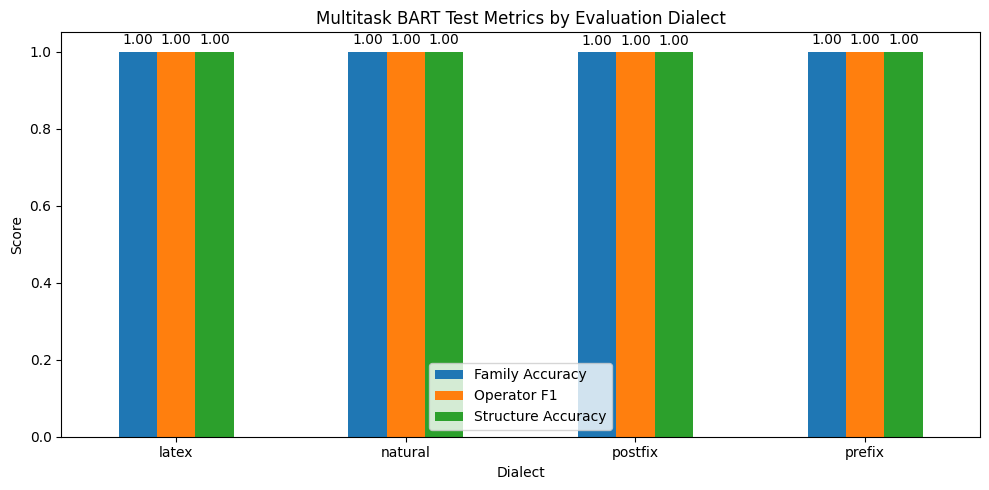

In [58]:
plot_df = multitask_test_df[['family_accuracy', 'operator_micro_f1', 'structure_accuracy']].copy()
plot_df.columns = ['Family Accuracy', 'Operator F1', 'Structure Accuracy']

ax = plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1.05), rot=0)
ax.set_title('Multitask BART Test Metrics by Evaluation Dialect')
ax.set_ylabel('Score')
ax.set_xlabel('Dialect')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()

In [59]:
config_summary = pd.DataFrame([
    {'Parameter': 'Model', 'Value': multitask_summary['config']['model_name']},
    {'Parameter': 'Device Preference', 'Value': NOTEBOOK_DEVICE},
    {'Parameter': 'Train Mode', 'Value': multitask_summary['config']['train_mode']},
    {'Parameter': 'Train Dialect', 'Value': multitask_summary['config']['train_dialect']},
    {'Parameter': 'Eval Dialects', 'Value': ', '.join(multitask_summary['config']['eval_dialects'])},
    {'Parameter': 'Held-Out Datasets', 'Value': ', '.join(multitask_summary['config'].get('held_out_datasets', [])) or 'none'},
    {'Parameter': 'Split Mode', 'Value': multitask_summary['config']['split_mode']},
    {'Parameter': 'Train / Val / Test Fractions', 'Value': f"{multitask_summary['config']['train_fraction']:.2f} / {multitask_summary['config']['val_fraction']:.2f} / {multitask_summary['config']['test_fraction']:.2f}"},
    {'Parameter': 'Batch Size', 'Value': multitask_summary['config']['batch_size']},
    {'Parameter': 'Epochs', 'Value': multitask_summary['config']['num_epochs']},
    {'Parameter': 'Learning Rate', 'Value': multitask_summary['config']['learning_rate']},
    {'Parameter': 'Max Input Length', 'Value': multitask_summary['config']['max_input_length']},
    {'Parameter': 'Operator Loss Weight', 'Value': multitask_summary['config']['operator_loss_weight']},
    {'Parameter': 'Structure Loss Weight', 'Value': multitask_summary['config']['structure_loss_weight']},
])

print('Run configuration:')
display(config_summary)


Run configuration:


,Parameter,Value
0,Model,facebook/bart-base
1,Device Preference,mps
2,Train Mode,mixed
3,Train Dialect,natural
4,Eval Dialects,"natural, latex, prefix, postfix"
5,Held-Out Datasets,"varied_data_generation/held_out_beam.jsonl, va..."
6,Split Mode,instance
7,Train / Val / Test Fractions,0.80 / 0.10 / 0.10
8,Batch Size,16
9,Epochs,4


## Phase 4: Apple MPS / Accelerate Runtime Check

This section checks whether the current notebook kernel can actually see Apple Metal (`mps`) and whether the installed `transformers` / `accelerate` stack exposes the flags we need.

Interpretation:
- If `MPS available in this kernel` is `True`, we can try `--device mps` for the fine-tuned runs.
- If it is `False`, this particular kernel/runtime should fall back to CPU even if PyTorch was built with MPS support.
- The helper scripts now disable `dataloader_pin_memory` on non-CUDA devices, which avoids the common Mac warning path.


In [60]:
training_args_signature = inspect.signature(TrainingArguments.__init__).parameters
runtime_rows = [
    {'Check': 'torch version', 'Value': torch.__version__},
    {'Check': 'transformers version', 'Value': transformers.__version__},
    {'Check': 'accelerate version', 'Value': accelerate.__version__},
    {'Check': 'MPS built into torch', 'Value': bool(getattr(torch.backends, 'mps', None) and torch.backends.mps.is_built())},
    {'Check': 'MPS available in this kernel', 'Value': bool(getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available())},
    {'Check': 'CUDA available', 'Value': bool(torch.cuda.is_available())},
    {'Check': 'Notebook device preference', 'Value': NOTEBOOK_DEVICE},
    {'Check': 'TrainingArguments supports use_mps_device', 'Value': 'use_mps_device' in training_args_signature},
    {'Check': 'TrainingArguments supports dataloader_pin_memory', 'Value': 'dataloader_pin_memory' in training_args_signature},
    {'Check': 'TrainingArguments supports use_cpu', 'Value': 'use_cpu' in training_args_signature},
]

display(pd.DataFrame(runtime_rows))
print('For long BART runs on a Mac, try `mps` first if it is available here; otherwise force `cpu` for stability.')


,Check,Value
0,torch version,2.9.0
1,transformers version,4.57.1
2,accelerate version,1.11.0
3,MPS built into torch,True
4,MPS available in this kernel,True
5,CUDA available,False
6,Notebook device preference,mps
7,TrainingArguments supports use_mps_device,True
8,TrainingArguments supports dataloader_pin_memory,True
9,TrainingArguments supports use_cpu,True


For long BART runs on a Mac, try `mps` first if it is available here; otherwise force `cpu` for stability.



## Phase 5: Fine-Tuned Cross-Dialect Validation Heatmap

This section fine-tunes **one BART classifier per dialect** and then evaluates each trained model on the **validation** split for every other dialect, giving a 4×4 cross-dialect heatmap.

Why this is separate from the multitask section:
- the multitask model is one shared encoder evaluated across dialects;
- this heatmap shows how well a model **fine-tuned on one dialect** transfers to another dialect.

The helper script now supports `--matrix-split val`, and the display cell below will automatically build the validation matrix the first time if it is missing.


In [61]:

RUN_CROSS_DIALECT_TRAINING = False
CROSS_DIALECT_OUTPUT_ROOT = Path('outputs') / 'bart_dialects_cross_val_80_10_10'
CROSS_DIALECT_MATRIX_SPLIT = 'val'
CROSS_DIALECT_MATRIX_PATH = CROSS_DIALECT_OUTPUT_ROOT / 'instance' / f'cross_dialect_accuracy_{CROSS_DIALECT_MATRIX_SPLIT}.csv'
CROSS_DIALECT_HEATMAP_PATH = CROSS_DIALECT_OUTPUT_ROOT / 'instance' / f'cross_dialect_accuracy_{CROSS_DIALECT_MATRIX_SPLIT}_heatmap.png'

CROSS_DIALECT_CMD = [
    sys.executable,
    'scripts/run_bart_cross_dialect_heatmap.py',
    '--output-root', str(CROSS_DIALECT_OUTPUT_ROOT),
    '--split-mode', 'instance',
    '--train-fraction', '0.8',
    '--val-fraction', '0.1',
    '--test-fraction', '0.1',
    '--matrix-split', CROSS_DIALECT_MATRIX_SPLIT,
    '--device', NOTEBOOK_DEVICE,
]

print('Fine-tuned cross-dialect validation command:')
print(' '.join(CROSS_DIALECT_CMD))
if RUN_CROSS_DIALECT_TRAINING:
    subprocess.run(CROSS_DIALECT_CMD + ['--force-retrain'], check=True)
else:
    print('The next cell will reuse an existing matrix or build it automatically if it is missing.')


Fine-tuned cross-dialect validation command:
/usr/local/bin/python3 scripts/run_bart_dialect_classification.py --output-root outputs/bart_dialects_cross_val_80_10_10 --split-mode instance --train-fraction 0.8 --val-fraction 0.1 --test-fraction 0.1 --cross-eval --cross-eval-split val --device mps
Set RUN_CROSS_DIALECT_TRAINING = True to launch the four fine-tuned dialect models and build the validation heatmap.


In [62]:

if not CROSS_DIALECT_MATRIX_PATH.exists():
    print(f'{CROSS_DIALECT_MATRIX_PATH} is missing. Building the validation matrix now...')
    subprocess.run(CROSS_DIALECT_CMD, check=True)

if not CROSS_DIALECT_MATRIX_PATH.exists():
    raise FileNotFoundError(
        f'{CROSS_DIALECT_MATRIX_PATH} was still not created. '
        'Inspect the command above or rerun the previous cell with RUN_CROSS_DIALECT_TRAINING = True.'
    )

cross_val_df = pd.read_csv(CROSS_DIALECT_MATRIX_PATH, index_col=0)
display(cross_val_df.style.format('{:.1f}'))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cross_val_df.values, cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(len(cross_val_df.columns)))
ax.set_xticklabels(cross_val_df.columns)
ax.set_yticks(range(len(cross_val_df.index)))
ax.set_yticklabels(cross_val_df.index)
ax.set_xlabel('Evaluation Dialect (validation split)')
ax.set_ylabel('Fine-Tuned On Dialect')
ax.set_title('Fine-Tuned BART Cross-Dialect Validation Accuracy')

for row_idx, row_name in enumerate(cross_val_df.index):
    for col_idx, col_name in enumerate(cross_val_df.columns):
        value = cross_val_df.loc[row_name, col_name]
        ax.text(col_idx, row_idx, f'{value:.1f}', ha='center', va='center', color='black', fontsize=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Family accuracy (%)')
plt.tight_layout()
plt.show()

if CROSS_DIALECT_HEATMAP_PATH.exists():
    print(f'Saved heatmap image: {CROSS_DIALECT_HEATMAP_PATH}')


FileNotFoundError: outputs/bart_dialects_cross_val_80_10_10/instance/cross_dialect_accuracy_val.csv does not exist yet. Run the cross-dialect training cell first.

## Phase 6: Split-Ratio Comparison

This section compares the current `80/10/10` split against `60/20/20` and `50/25/25` using the **same multitask BART workflow**.

Important reading note:
- this still uses the current `instance` split unless you explicitly switch the command to `--split-mode equation`;
- because the symbolic dataset still has heavy repetition, different ratio comparisons should be interpreted together with the audit section below.


In [ ]:
SPLIT_EXPERIMENTS = [
    {'label': '80/10/10', 'tag': '80_10_10', 'train_fraction': 0.8, 'val_fraction': 0.1, 'test_fraction': 0.1},
    {'label': '60/20/20', 'tag': '60_20_20', 'train_fraction': 0.6, 'val_fraction': 0.2, 'test_fraction': 0.2},
    {'label': '50/25/25', 'tag': '50_25_25', 'train_fraction': 0.5, 'val_fraction': 0.25, 'test_fraction': 0.25},
]
RUN_SPLIT_EXPERIMENTS = False
SPLIT_COMPARE_RUNS = []

for experiment in SPLIT_EXPERIMENTS:
    output_root = Path('outputs') / f"bart_multitask_split_compare_{experiment['tag']}"
    cmd = [
        sys.executable,
        'scripts/run_bart_multitask_pde.py',
        '--train-mode', 'mixed',
        '--split-mode', 'instance',
        '--output-root', str(output_root),
        '--train-fraction', str(experiment['train_fraction']),
        '--val-fraction', str(experiment['val_fraction']),
        '--test-fraction', str(experiment['test_fraction']),
        '--device', NOTEBOOK_DEVICE,
    ]
    if HELD_OUT_DATASETS:
        cmd.extend(['--held-out-datasets', *[str(path) for path in HELD_OUT_DATASETS]])
    SPLIT_COMPARE_RUNS.append({'experiment': experiment, 'output_root': output_root, 'cmd': cmd})
    print(f"[{experiment['label']}] {' '.join(cmd)}")

if RUN_SPLIT_EXPERIMENTS:
    for run in SPLIT_COMPARE_RUNS:
        print(f"\nRunning split experiment {run['experiment']['label']}")
        subprocess.run(run['cmd'], check=True)
else:
    print('Set RUN_SPLIT_EXPERIMENTS = True to launch all split-comparison training jobs.')


In [ ]:
split_compare_rows = []
held_out_compare_rows = []

for run in SPLIT_COMPARE_RUNS:
    experiment = run['experiment']
    metrics_path = run['output_root'] / 'instance' / 'mixed' / 'multitask_metrics.json'
    if not metrics_path.exists():
        print(f"Skipping {experiment['label']} because {metrics_path} does not exist yet.")
        continue

    with open(metrics_path) as handle:
        summary = json.load(handle)

    test_df = pd.DataFrame(summary['test_metrics']).T.sort_index()
    split_row = {
        'Split': experiment['label'],
        'Mean Family Acc': test_df['family_accuracy'].mean(),
        'Mean Operator F1': test_df['operator_micro_f1'].mean(),
        'Mean Structure Acc': test_df['structure_accuracy'].mean(),
        'Best Family Dialect': test_df['family_accuracy'].idxmax(),
        'Best Operator Dialect': test_df['operator_micro_f1'].idxmax(),
        'Best Structure Dialect': test_df['structure_accuracy'].idxmax(),
    }

    held_out_rows_for_split = []
    for dataset_name, dataset_metrics in summary.get('held_out_metrics', {}).items():
        dataset_df = pd.DataFrame(dataset_metrics).T.sort_index()
        dataset_info = HELD_OUT_DATASET_INFO.get(dataset_name, {})
        held_out_compare_rows.append({
            'Split': experiment['label'],
            'Held-Out Family': dataset_info.get('display_name', dataset_name),
            'Closest Seen Family': dataset_info.get('closest_seen_family', 'Unknown'),
            'Mean Operator F1': dataset_df['operator_micro_f1'].mean(),
            'Mean Structure Acc': dataset_df['structure_accuracy'].mean(),
        })
        held_out_rows_for_split.append(dataset_df)

    if held_out_rows_for_split:
        combined_held_out_df = pd.concat(held_out_rows_for_split)
        split_row['Mean Held-Out Operator F1'] = combined_held_out_df['operator_micro_f1'].mean()
        split_row['Mean Held-Out Structure Acc'] = combined_held_out_df['structure_accuracy'].mean()

    split_compare_rows.append(split_row)

if not split_compare_rows:
    raise FileNotFoundError('No split-comparison metrics found yet. Run the split experiment cell first.')

split_compare_df = pd.DataFrame(split_compare_rows).set_index('Split').sort_index()
display(split_compare_df.style.format({
    'Mean Family Acc': '{:.2%}',
    'Mean Operator F1': '{:.2%}',
    'Mean Structure Acc': '{:.2%}',
    'Mean Held-Out Operator F1': '{:.2%}',
    'Mean Held-Out Structure Acc': '{:.2%}',
}, na_rep='n/a'))

plot_cols = [column for column in [
    'Mean Family Acc',
    'Mean Operator F1',
    'Mean Structure Acc',
    'Mean Held-Out Operator F1',
    'Mean Held-Out Structure Acc',
] if column in split_compare_df.columns]

ax = split_compare_df[plot_cols].plot(kind='bar', figsize=(10, 5), ylim=(0, 1.05), rot=0)
ax.set_title('BART Multitask Performance by Train/Val/Test Split Ratio')
ax.set_ylabel('Score')
ax.set_xlabel('Split ratio')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()

if held_out_compare_rows:
    held_out_compare_df = pd.DataFrame(held_out_compare_rows).sort_values(
        by=['Held-Out Family', 'Split']
    )
    print('Held-out comparison by split ratio:')
    display(held_out_compare_df.style.format({
        'Mean Operator F1': '{:.2%}',
        'Mean Structure Acc': '{:.2%}',
    }))


## Phase 7: Varied-Data Generation Audit

This section audits the current `varied_data_generation` pipeline to answer a key question: are we really forcing the model to read PDE structure, or can it still get away with appearance matching?

The code below looks at repeated equation signatures and train/test overlap under the current `80/10/10` instance split.


In [ ]:
from collections import Counter

if 'scripts' not in sys.path:
    sys.path.append('scripts')

from dialect_utils import DIALECTS as AUDIT_DIALECTS, equation_signature, exact_input_overlap, load_jsonl, stratified_instance_split

varied_data = load_jsonl('varied_data_generation/dataset.jsonl')
signature_counts = Counter(equation_signature(instance) for instance in varied_data)

family_audit_rows = []
for family in sorted({instance['family'] for instance in varied_data}):
    family_instances = [instance for instance in varied_data if instance['family'] == family]
    unique_equations = len({equation_signature(instance) for instance in family_instances})
    family_audit_rows.append({
        'Family': family,
        'Instances': len(family_instances),
        'Unique Equation Groups': unique_equations,
        'Average Repeats Per Equation': len(family_instances) / unique_equations,
    })

family_audit_df = pd.DataFrame(family_audit_rows).set_index('Family')
display(family_audit_df.style.format({'Average Repeats Per Equation': '{:.2f}'}))

train_audit, val_audit, test_audit = stratified_instance_split(
    varied_data,
    seed=42,
    train_fraction=0.8,
    val_fraction=0.1,
    test_fraction=0.1,
)

overlap_rows = []
for dialect in AUDIT_DIALECTS:
    overlap = exact_input_overlap(train_audit, test_audit, dialect)
    overlap_rows.append({
        'Dialect': dialect,
        'Exact Overlap Examples': overlap['overlap_examples'],
        'Exact Overlap Rate': overlap['overlap_rate'],
        'Unique Overlap': overlap['overlap_unique'],
    })

overlap_df = pd.DataFrame(overlap_rows).set_index('Dialect')
display(overlap_df.style.format({'Exact Overlap Rate': '{:.2%}'}))

most_repeated_signature, most_repeated_count = signature_counts.most_common(1)[0]
print(f'Most repeated equation signature appears {most_repeated_count} times: {most_repeated_signature}')


### What To Change If We Want More Structural Understanding Than Appearance Matching

After inspecting `varied_data_generation/sampler.py`, `varied_data_generation/pde_templates.py`, and `varied_data_generation/converters.py`, the current varied-data pipeline is **better than the original single-template setup**, but it can still reward shortcut learning.

Main reasons:
- `sample_coefficients` rounds values to **two decimals**, so the same symbolic equation signature repeats many times.
- Each family still has a largely fixed symbolic skeleton in LaTeX / prefix / postfix, so the symbolic dialects are close to template matching.
- The operator target set is fixed by family, so a model can often infer operators from family identity alone.
- Several reasoning templates explicitly name the family or the distinguishing clue, which makes explanation generation easier than true grounded reasoning.

Concrete next changes I recommend:
- Increase coefficient diversity: use 3–4 decimals, symbolic coefficients, or sample coefficient grids without replacement.
- Add algebraically equivalent rewrites: move all terms to one side, multiply by `-1`, reorder additive terms, and vary where coefficients appear.
- Create adversarial near-neighbor pairs: `Heat` vs `ReactionDiffusion`, `Wave` vs `KleinGordon`, `Wave` vs `Beam`.
- Make the operator task less family-deterministic, or at least add distractor operators / ambiguous cases.
- Use `split-mode equation` or coefficient-blocked splits for the real benchmark, not only instance-level splitting.
- Keep the held-out structural mapping visible in the notebook, but do **not** leak that mapping into training text.

Bottom line:
- the current pipeline already randomizes natural-language and reasoning templates,
- but the symbolic forms still make it too easy to recognize surface family signatures,
- so stronger algebraic variation and stricter splitting are the biggest next step if the goal is genuine PDE understanding.


## Phase 8: Shared vs Single-Dialect Multitask Comparison

The shared model above fine-tunes on all four representations together.
This section adds four more multitask runs:
- `single_natural`
- `single_latex`
- `single_prefix`
- `single_postfix`

Each single-dialect model is trained on only one representation, but it is still evaluated on all four evaluation dialects and on the held-out families. That lets us compare:
- average cross-dialect robustness
- transfer from one training representation into the other three
- held-out structural generalization beyond the shared-data baseline


In [ ]:
SINGLE_DIALECT_RUNS = []

for dialect in PDE_DIALECTS:
    output_dir = MULTITASK_ROOT_DIR / f'single_{dialect}'
    metrics_path = output_dir / 'multitask_metrics.json'
    cmd = [
        sys.executable,
        'scripts/run_bart_multitask_pde.py',
        '--train-mode', 'single',
        '--train-dialect', dialect,
        '--split-mode', 'instance',
        '--device', NOTEBOOK_DEVICE,
    ]
    if HELD_OUT_DATASETS:
        cmd.extend(['--held-out-datasets', *[str(path) for path in HELD_OUT_DATASETS]])

    SINGLE_DIALECT_RUNS.append({
        'dialect': dialect,
        'label': f'Single ({dialect})',
        'output_dir': output_dir,
        'metrics_path': metrics_path,
        'cmd': cmd,
    })
    print(f"[{dialect}] {' '.join(cmd)}")

for run in SINGLE_DIALECT_RUNS:
    print(f"\nRunning {run['label']} -> {run['output_dir']}")
    subprocess.run(run['cmd'], check=True)


In [ ]:
MODEL_RUN_SPECS = [
    {
        'model_key': 'shared_mixed',
        'label': 'Shared (all 4 dialects)',
        'training_representation': 'natural + latex + prefix + postfix',
        'metrics_path': MULTITASK_METRICS_PATH,
    }
]

for dialect in PDE_DIALECTS:
    MODEL_RUN_SPECS.append(
        {
            'model_key': f'single_{dialect}',
            'label': f'Single ({dialect})',
            'training_representation': dialect,
            'metrics_path': MULTITASK_ROOT_DIR / f'single_{dialect}' / 'multitask_metrics.json',
        }
    )

missing_metrics = [
    str(spec['metrics_path'])
    for spec in MODEL_RUN_SPECS
    if not spec['metrics_path'].exists()
]
if missing_metrics:
    raise FileNotFoundError(
        'Missing multitask metric files. Run the shared-model cell and the single-dialect training cell first:\n'
        + '\n'.join(missing_metrics)
    )

model_order = [spec['label'] for spec in MODEL_RUN_SPECS]
overall_rows = []
per_dialect_rows = []
held_out_compare_rows = []

for spec in MODEL_RUN_SPECS:
    with open(spec['metrics_path']) as handle:
        summary = json.load(handle)

    test_df = pd.DataFrame(summary['test_metrics']).T.sort_index()
    overall_row = {
        'Model': spec['label'],
        'Training Representation': spec['training_representation'],
        'Mean Family Acc': test_df['family_accuracy'].mean(),
        'Mean Operator F1': test_df['operator_micro_f1'].mean(),
        'Mean Structure Acc': test_df['structure_accuracy'].mean(),
        'Best Eval Dialect (Family)': test_df['family_accuracy'].idxmax(),
        'Best Eval Dialect (Operator)': test_df['operator_micro_f1'].idxmax(),
        'Best Eval Dialect (Structure)': test_df['structure_accuracy'].idxmax(),
    }

    for eval_dialect, row in test_df.iterrows():
        per_dialect_rows.append(
            {
                'Model': spec['label'],
                'Training Representation': spec['training_representation'],
                'Eval Dialect': eval_dialect,
                'Family Acc': row['family_accuracy'],
                'Operator F1': row['operator_micro_f1'],
                'Structure Acc': row['structure_accuracy'],
            }
        )

    held_out_frames = []
    for dataset_name, dataset_metrics in summary.get('held_out_metrics', {}).items():
        dataset_df = pd.DataFrame(dataset_metrics).T.sort_index()
        dataset_info = HELD_OUT_DATASET_INFO.get(dataset_name, {})
        top_predicted_family = ''
        if 'top_predicted_family' in dataset_df.columns:
            non_null_predictions = dataset_df['top_predicted_family'].dropna()
            if not non_null_predictions.empty:
                top_predicted_family = non_null_predictions.mode().iat[0]

        held_out_compare_rows.append(
            {
                'Model': spec['label'],
                'Training Representation': spec['training_representation'],
                'Held-Out Family': dataset_info.get('display_name', dataset_name),
                'Closest Seen Family': dataset_info.get('closest_seen_family', 'Unknown'),
                'Mean Operator F1': dataset_df['operator_micro_f1'].mean(),
                'Mean Structure Acc': dataset_df['structure_accuracy'].mean(),
                'Most Common Predicted Family': top_predicted_family,
            }
        )
        held_out_frames.append(dataset_df)

    if held_out_frames:
        combined_held_out_df = pd.concat(held_out_frames)
        overall_row['Mean Held-Out Operator F1'] = combined_held_out_df['operator_micro_f1'].mean()
        overall_row['Mean Held-Out Structure Acc'] = combined_held_out_df['structure_accuracy'].mean()

    overall_rows.append(overall_row)

overall_compare_df = pd.DataFrame(overall_rows).set_index('Model').loc[model_order]
print('Overall comparison across the shared model and the four single-dialect models:')
display(overall_compare_df.style.format({
    'Mean Family Acc': '{:.2%}',
    'Mean Operator F1': '{:.2%}',
    'Mean Structure Acc': '{:.2%}',
    'Mean Held-Out Operator F1': '{:.2%}',
    'Mean Held-Out Structure Acc': '{:.2%}',
}, na_rep='n/a'))

per_dialect_compare_df = pd.DataFrame(per_dialect_rows)
per_dialect_compare_df['Model'] = pd.Categorical(
    per_dialect_compare_df['Model'], categories=model_order, ordered=True
)
per_dialect_compare_df['Eval Dialect'] = pd.Categorical(
    per_dialect_compare_df['Eval Dialect'], categories=PDE_DIALECTS, ordered=True
)
per_dialect_compare_df = per_dialect_compare_df.sort_values(['Eval Dialect', 'Model']).reset_index(drop=True)
print('Per-evaluation-dialect comparison:')
display(per_dialect_compare_df.style.format({
    'Family Acc': '{:.2%}',
    'Operator F1': '{:.2%}',
    'Structure Acc': '{:.2%}',
}))

if held_out_compare_rows:
    held_out_compare_df = pd.DataFrame(held_out_compare_rows)
    held_out_compare_df['Model'] = pd.Categorical(
        held_out_compare_df['Model'], categories=model_order, ordered=True
    )
    held_out_compare_df = held_out_compare_df.sort_values(['Held-Out Family', 'Model']).reset_index(drop=True)
    print('Held-out family comparison with readable annotations:')
    display(held_out_compare_df.style.format({
        'Mean Operator F1': '{:.2%}',
        'Mean Structure Acc': '{:.2%}',
    }))

print(
    f"Best mean family accuracy: {overall_compare_df['Mean Family Acc'].idxmax()} "
    f"({overall_compare_df['Mean Family Acc'].max():.2%})"
)
print(
    f"Best mean operator F1: {overall_compare_df['Mean Operator F1'].idxmax()} "
    f"({overall_compare_df['Mean Operator F1'].max():.2%})"
)
print(
    f"Best mean structure accuracy: {overall_compare_df['Mean Structure Acc'].idxmax()} "
    f"({overall_compare_df['Mean Structure Acc'].max():.2%})"
)


In [ ]:
plot_columns = ['Mean Family Acc', 'Mean Operator F1', 'Mean Structure Acc']
has_held_out_summary = {
    'Mean Held-Out Operator F1',
    'Mean Held-Out Structure Acc',
}.issubset(overall_compare_df.columns)

if has_held_out_summary:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    test_ax, held_out_ax = axes
else:
    fig, test_ax = plt.subplots(1, 1, figsize=(10, 5))
    held_out_ax = None

overall_compare_df[plot_columns].plot(
    kind='bar',
    ax=test_ax,
    ylim=(0, 1.05),
    rot=15,
)
test_ax.set_title('Average Test Metrics Across Evaluation Dialects')
test_ax.set_ylabel('Score')
test_ax.set_xlabel('Training setup')
for container in test_ax.containers:
    test_ax.bar_label(container, fmt='%.2f', padding=3)

if held_out_ax is not None:
    overall_compare_df[['Mean Held-Out Operator F1', 'Mean Held-Out Structure Acc']].plot(
        kind='bar',
        ax=held_out_ax,
        ylim=(0, 1.05),
        rot=15,
        color=['#6c757d', '#2a9d8f'],
    )
    held_out_ax.set_title('Average Held-Out Metrics Across Held-Out Families')
    held_out_ax.set_ylabel('Score')
    held_out_ax.set_xlabel('Training setup')
    for container in held_out_ax.containers:
        held_out_ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()


## Conclusion

This notebook now combines the shared multitask BART workflow with a fuller analysis layer: detailed metric definitions, held-out-family annotations, an Apple MPS / `accelerate` runtime check, a fine-tuned cross-dialect validation heatmap section, split-ratio comparison cells, a varied-data audit, and a final shared-vs-single-dialect model comparison.

That makes it easier to separate three questions:
- how well a model fits the current split
- how well it transfers across representations
- how much of the signal looks structural instead of just surface-form matching
